In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [2]:
device = "cpu"

In [3]:
class MyNeuralNet(nn.Module):
    def __init__(self, layers, size_list):
        super().__init__()

        self.input_size, self.hidden_size, self.output_size = size_list

        self.layers = nn.ModuleList()
        self.bns = nn.ModuleList()

        # First layer
        self.layers.append(nn.Linear(self.input_size, self.hidden_size))
        self.bns.append(nn.BatchNorm1d(self.hidden_size))

        # Hidden layers
        for _ in range(layers - 2):
            self.layers.append(nn.Linear(self.hidden_size, self.hidden_size))
            self.bns.append(nn.BatchNorm1d(self.hidden_size))

        # Output
        self.out = nn.Linear(self.hidden_size, self.output_size)
        
    def init_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        for i in range(len(self.layers)):
            identity = x
    
            x = self.layers[i](x)
            x = self.bns[i](x)
            x = torch.relu(x)
    
            # Add skip connection (only if dimensions match)
            if x.shape == identity.shape:
                x = x + identity
    
        return self.out(x)

In [4]:
def make_spirals(n_samples=300, noise=0.1, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
        
    n = n_samples // 2
    theta = np.sqrt(np.random.rand(n)) * 2 * np.pi
    
    r_a = 2 * theta + np.pi
    data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
    data_a += np.random.randn(n, 2) * noise
    
    r_b = -2 * theta - np.pi
    data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
    data_b += np.random.randn(n, 2) * noise
    
    X = np.vstack([data_a, data_b])
    y = np.zeros(n_samples, dtype=int)
    y[n:] = 1
    
    return X, y


In [15]:
def make_complex_spirals(n_samples=3000, noise=0.5, rotations=3, random_state=None):
    """
    Generates a much more complex dataset where the spirals wrap around each other
    multiple times (controlled by 'rotations'), creating a highly non-linear
    decision boundary that requires a deeper/smarter network to solve.
    """
    if random_state is not None:
        np.random.seed(random_state)
        
    n = n_samples // 2
    
    # Increase the maximum angle to make the spirals wrap around more
    theta = np.sqrt(np.random.rand(n)) * rotations * 2 * np.pi
    
    # Class 0
    r_a = theta + np.pi
    data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
    data_a += np.random.randn(n, 2) * noise
    
    # Class 1
    r_b = -theta - np.pi
    data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
    data_b += np.random.randn(n, 2) * noise
    
    X = np.vstack([data_a, data_b])
    y = np.zeros(n_samples, dtype=int)
    y[n:] = 1
    
    return X, y

In [16]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

X, y = make_complex_spirals(n_samples=3000, noise=1.4, random_state=42)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

len(train_loader)

9

In [22]:
model = MyNeuralNet(35,[2,16,1])
model.to(device)
model.init_weights()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
epochs = 1000

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() 
    train_loss /= len(train_loader)
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {train_loss:.4f}")
    
print("Final Loss:", train_loss)

Epoch 0, Loss: 0.7207
Epoch 50, Loss: 0.5438
Epoch 100, Loss: 0.5089
Epoch 150, Loss: 0.5044
Epoch 200, Loss: 0.4955
Epoch 250, Loss: 0.4738
Epoch 300, Loss: 0.5241
Epoch 350, Loss: 0.5167
Epoch 400, Loss: 0.4783
Epoch 450, Loss: 0.5125
Epoch 500, Loss: 0.5078
Epoch 550, Loss: 0.4824
Epoch 600, Loss: 0.5388
Epoch 650, Loss: 0.5154
Epoch 700, Loss: 0.4996
Epoch 750, Loss: 0.4486
Epoch 800, Loss: 0.5077
Epoch 850, Loss: 0.4564
Epoch 900, Loss: 0.5073
Epoch 950, Loss: 0.4840
Final Loss: 0.46049806475639343


In [23]:
model.eval()
test_loss = 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item()
test_loss /= len(test_loader)
print(f"Train Loss={train_loss:.4f},\nTest Loss={test_loss:.4f}")

Train Loss=0.4605,
Test Loss=0.4989


In [24]:
def evaluate(loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

print("Train Acc:", evaluate(train_loader) * 100)
print("Test Acc:", evaluate(test_loader) * 100)

Train Acc: 80.76190476190476
Test Acc: 76.88888888888889


In [10]:
def plot_decision_boundary(model, X, y):
    model.eval()
    
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    grid = grid.to(device)
    
    with torch.no_grad():
        logits = model(grid)
        probs = torch.sigmoid(logits)
    
    Z = probs.cpu().reshape(xx.shape).numpy()
    
    plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap="coolwarm", edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()

In [11]:
def plot_3d_surface(model, X, y):
    model.eval()

    # Create grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    grid = grid.to(device)

    # Get predictions
    with torch.no_grad():
        logits = model(grid)
        probs = torch.sigmoid(logits)

    Z = probs.cpu().reshape(xx.shape).numpy()

    # Plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(xx, yy, Z, alpha=0.6)
    
    # Scatter original points
    ax.scatter(
        X[:, 0], X[:, 1], y.squeeze(),
        c=y.squeeze(), cmap='coolwarm', edgecolor='k'
    )

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Probability")
    ax.set_title("3D Decision Surface")

    plt.show()

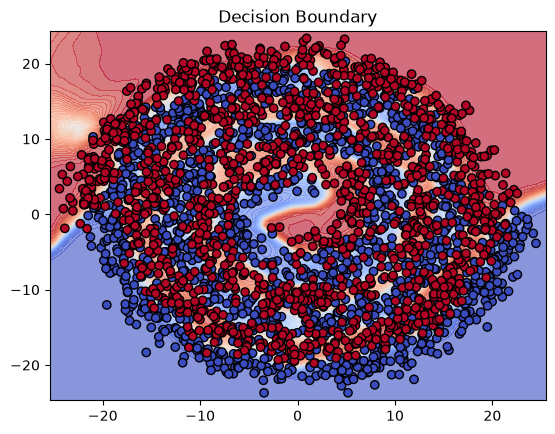

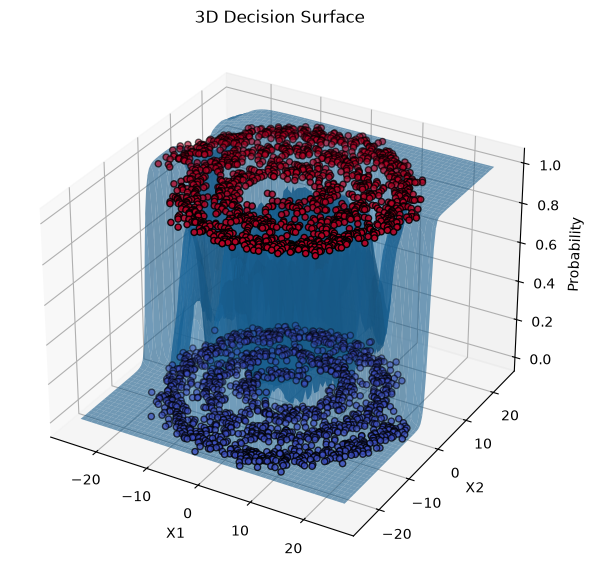

In [25]:
plot_decision_boundary(model, X.cpu().numpy(), y.cpu().numpy())
plot_3d_surface(model, X.cpu().numpy(), y.cpu().numpy())

In [13]:
for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad)
        print()

layers.0.weight tensor([[-0.0885, -0.0352],
        [-0.0293,  0.0003],
        [-0.0062,  0.0086],
        [ 0.0030,  0.0853],
        [-0.2234, -0.0685],
        [-0.0967,  0.0643],
        [ 0.0120,  0.0081],
        [-0.0013, -0.0010],
        [-0.0149,  0.0257],
        [ 0.0007, -0.0018],
        [-0.0843,  0.0231],
        [-0.0691, -0.0025],
        [ 0.0732,  0.1955],
        [ 0.0155,  0.1179],
        [ 0.0230,  0.0265],
        [-0.0567, -0.0319]])

layers.0.bias tensor([ 1.8626e-09, -5.8208e-11,  0.0000e+00,  0.0000e+00, -1.1642e-09,
        -1.6298e-09, -7.5670e-10, -8.7311e-10, -3.4925e-10,  4.6566e-10,
        -5.8208e-11,  2.9104e-10,  3.7253e-09,  3.4925e-10,  8.7311e-11,
        -8.1491e-10])

layers.1.weight tensor([[-1.8905e-02, -1.9718e-02,  1.5259e-03,  3.0689e-03, -1.8983e-03,
         -8.9800e-03, -1.4825e-02, -1.2570e-02, -6.4339e-04, -4.7578e-05,
         -2.4401e-03, -1.8567e-02,  9.5436e-03, -3.8213e-03, -2.6814e-02,
         -2.8669e-03],
        [ 1.6416e